In [2]:
import sys
import os
sys.path.append(os.path.abspath('../src'))

# cc-optimal example

--- Gamma = 0.05 ---
Optimal Lambda : 0.43
Eff_mu         : 0.802
Eff_eta        : 0.911
Design (Probability -> Weight):
0.103    0.638
0.897    0.362
dtype: float64

--- Gamma = 0.15 ---
Optimal Lambda : 0.82
Eff_mu         : 0.804
Eff_eta        : 0.552
Design (Probability -> Weight):
0.148    0.805
0.852    0.195
dtype: float64

--- Gamma = 0.3 ---
Optimal Lambda : 0.87
Eff_mu         : 0.803
Eff_eta        : 0.438
Design (Probability -> Weight):
0.227    0.761
0.773    0.239
dtype: float64



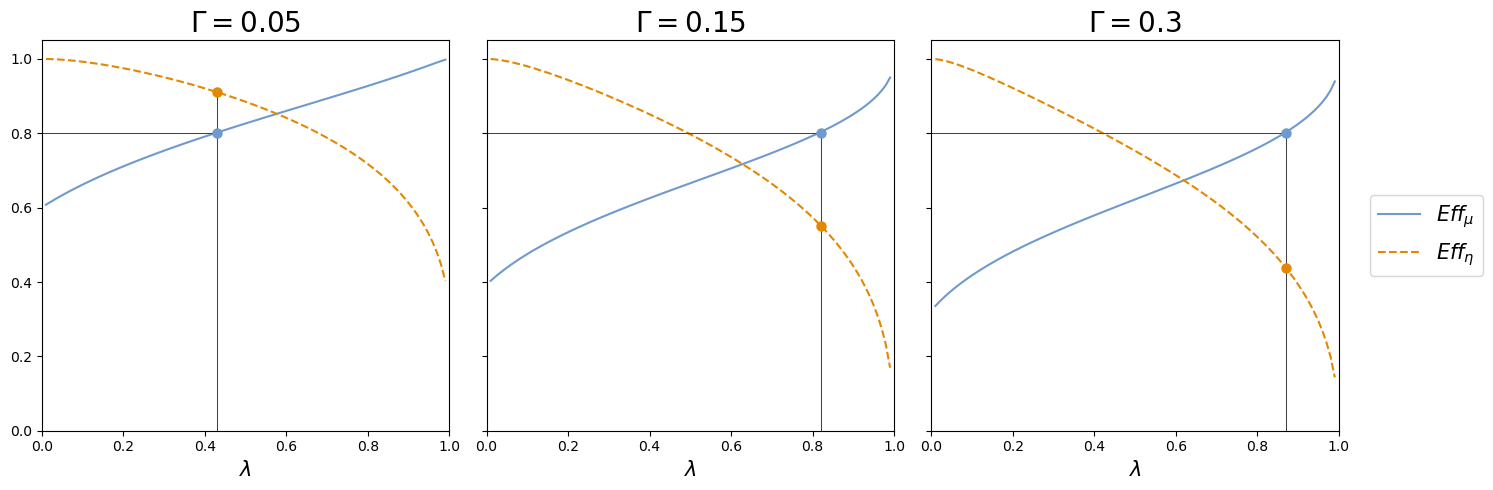

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from optimal_designs import cc_optimal
from reparameterization import load_param

# 1. SETUP
model_name = 'logistic'
gamma_values = [0.05, 0.15, 0.30]
eval_tolerance = 0.8

# 2. PLOTTING SETUP
COLORS = {
    'r': '#bf775f', 'r2': '#d5572c', 'o': "#e38800", 'y': '#e6d26b',
    'g': "#648B00", 'c': '#98cacd', 'b': '#709acd', 'p': "#645697", 
    'gr': '#444444', 'b2': '#4c72b0'
}

fig, axes = plt.subplots(figsize=(15, 5), ncols=3, sharex=True, sharey=True)

# 3. ITERATING AND PLOTTING
for i, g_val in enumerate(gamma_values):
    ax = axes[i]
    
    # Extract the full efficiency curves dynamically using the master function
    # By setting tolerance=None, it returns the DataFrame instead of the optimal design
    df_curve = cc_optimal(model=model_name, g=g_val, m=0.5, tolerance=None, approx=True, warning=False)
    
    # Plot the efficiency curves directly from the DataFrame
    ax.plot(df_curve.index, df_curve['mu'], color=COLORS['b'], label=r'$Eff_\mu$' if i==0 else "")
    ax.plot(df_curve.index, df_curve['eta'], color=COLORS['o'], ls='--', label=r'$Eff_\eta$' if i==0 else "")
    
    # Find the optimal lambda post-hoc based on our evaluation tolerance
    valid_lambdas = df_curve[df_curve['mu'] >= eval_tolerance]
    
    if not valid_lambdas.empty:
        opt_lambda = valid_lambdas['eta'].idxmax()
        val_mu = df_curve.loc[opt_lambda, 'mu']
        val_eta = df_curve.loc[opt_lambda, 'eta']
        
        # Draw the intersection and boundary lines
        ax.plot([0, opt_lambda], [eval_tolerance, eval_tolerance], color=COLORS['gr'], lw=0.75)
        ax.scatter([opt_lambda], [eval_tolerance], color=COLORS['b'], lw=1.5, zorder=3)
        
        ax.plot([opt_lambda, opt_lambda], [0, max(val_eta, val_mu)], color=COLORS['gr'], lw=0.75)
        ax.scatter([opt_lambda], [val_eta], color=COLORS['o'], lw=1.5, zorder=3)
        
        # Text Reporting
        print(f"--- Gamma = {g_val} ---")
        print(f"Optimal Lambda : {opt_lambda:.2f}")
        print(f"Eff_mu         : {val_mu:.3f}")
        print(f"Eff_eta        : {val_eta:.3f}")
        
        # Retrieve the final optimal design automatically using the master function again
        dis_opt, _ = cc_optimal(model=model_name, g=g_val, m=0.5, tolerance=eval_tolerance, approx=True, warning=False)
        
        # Transform doses to probabilities for the report
        H_func = load_param(model=model_name, g=g_val, m=0.5)['H']
        prob_index = H_func(dis_opt.index.to_numpy()).round(3)
        dis_opt_report = pd.Series(dis_opt.values.round(3), index=prob_index)
        
        print(f"Design (Probability -> Weight):\n{dis_opt_report}\n")
        
    ax.set_title(rf'$\Gamma = {g_val}$', size=20)
    ax.set_xlabel(r'$\lambda$', size=15)
    ax.set_ylim(0, 1.05)
    ax.set_xlim(0, 1.0)

# Extract legend from the first axis and place it outside the last one
handles, labels = axes[0].get_legend_handles_labels()
axes[2].legend(handles, labels, loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize=15, frameon=True)

plt.tight_layout()
plt.show()